# Imports

In [1]:
import os
import sys

In [2]:
current_dir =  os.getcwd()
# replace this following line in the path your frank2d files are.
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [4]:
# frank2d
from frank2d import Frank2D
from frank2d.geometry import Geometry
from frank2d.plot import Plot
from frank2d.posterior_optimization import *
from frank2d.constants import rad_to_arcsec, deg_to_rad

# Data

In [5]:
AS209 = {'inc': 34.97, 'pa': 85.76, 'dra':1.9e-3, 'ddec':-2.5e-3, 'rout': 1.2*2, 'disk_name': 'AS209'}
IMLup = {'inc': 47.5, 'pa': 144.5, 'dra':-1.5e-3, 'ddec':1e-3, 'rout': 1.71*2, 'disk_name': 'IMLup'}
Elias27 = {'inc': 56.2, 'pa': 118.8, 'dra':-5e-3, 'ddec':-8e-3, 'rout': 1.88*2, 'disk_name': 'Elias27'}
HD163296 = {'inc':46.7, 'pa':133.33, 'dra':-2.8e-3, 'ddec':7.7e-3, 'rout':1.7*2, 'disk_name': 'HD163296' }
Elias24 = {'inc': 29, 'pa': 45.7, 'dra':110.8e-3, 'ddec':-386.8e-3, 'rout': 1.03*2, 'disk_name': 'Elias24'}
HD143006 = {'inc': 18.6, 'pa': 169, 'dra':-5.9e-3, 'ddec':21.7e-3, 'rout': 0.518*3, 'disk_name': 'HD143006'}

In [6]:
data = AS209

dir = "/Users/mariajmelladot/Desktop/Frank2D/data/uvtables/"
disk_name = data['disk_name']
data_file = dir +"uvtable_" + disk_name + "_continuum.npz"

# Huang 2018 
inc = data['inc']
pa = data['pa']
dra = data['dra']
ddec = data['ddec']
rout = data['rout']

In [7]:
# Frank Parameters
N = 300
 # load data
file = np.load(data_file)
u, v, Re, Im, Weights = file['u'], file['v'], file['Re'], file['Im'], file['w']
Vis = Re + Im*1j

# F2D

In [9]:
geom = Geometry(inc, pa, dra, ddec)
frank2d = Frank2D(N, rout, geom)

In [10]:
frank2d.process_vis(u, v, Vis, Weights)

Shifted grid..
Setting gridded data...


### Run

Setting GP Kernel Wendland...
Creating sparse linear system...
--> time = 0.64  min |  38.59 seconds
Solving linear system...
         * rtol: 1e-08
         * final tolerance: 2.881751982790495
Final tolerance :  2.881751982790495
.... iteration:  0
                        -> actual tol:  288175198.2790495 vs  2.881751982790495
.... iteration:  1
                        -> actual tol:  47937660.42240118 vs  2.881751982790495
.... iteration:  2
                        -> actual tol:  35849612.92128815 vs  2.881751982790495
.... iteration:  3
                        -> actual tol:  32541700.333215173 vs  2.881751982790495
.... iteration:  4
                        -> actual tol:  32251754.364362568 vs  2.881751982790495
.... iteration:  5
                        -> actual tol:  31649617.258955788 vs  2.881751982790495
.... iteration:  6
                        -> actual tol:  31566363.392503932 vs  2.881751982790495
.... iteration:  7
                        -> actual tol:  30576847.672

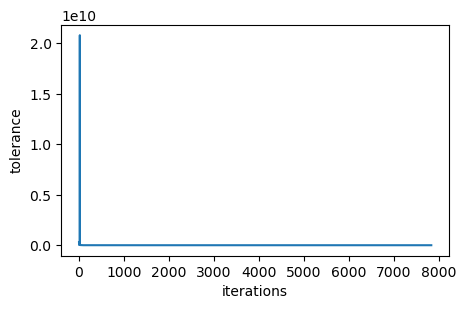

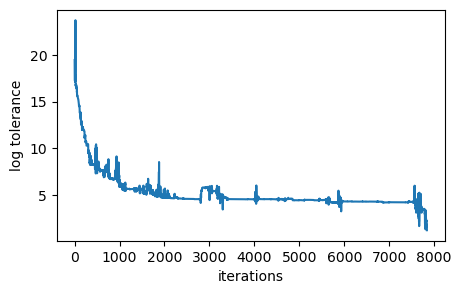

--> time = 7.86  min |  471.80 seconds
-> CGM converged?   True
-> Fit correctly?   True
!!!!  Sucess  !!!!
Building full visibility model...
F2D model in 10.08 minutes.


In [10]:
start_time = time.time()

kernel_params =  {'m': -2, 'c': 1e8, 'l': 1e5}
frank2d.fit(kernel_params = kernel_params, rtol = 1e-8 )

end_time = time.time()
print(f"F2D model in {(end_time - start_time)/60:.2f} minutes.")

## Richard's optimization

Setting GP Kernel Wendland...
Creating sparse linear system...
--> time = 0.08  min |  4.68 seconds
Solving linear system...
         * rtol: 1e-08
         * final tolerance: 2.881751982790495
Final tolerance :  2.881751982790495
.... iteration:  0
                        -> actual tol:  288175198.2790495 vs  2.881751982790495
.... iteration:  1
                        -> actual tol:  47937660.42240118 vs  2.881751982790495
.... iteration:  2
                        -> actual tol:  35849612.92128815 vs  2.881751982790495
.... iteration:  3
                        -> actual tol:  32541700.333215173 vs  2.881751982790495
.... iteration:  4
                        -> actual tol:  32251754.364362568 vs  2.881751982790495
.... iteration:  5
                        -> actual tol:  31649617.258955788 vs  2.881751982790495
.... iteration:  6
                        -> actual tol:  31566363.392503932 vs  2.881751982790495
.... iteration:  7
                        -> actual tol:  30576847.6726

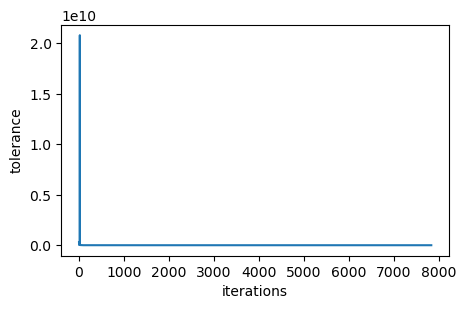

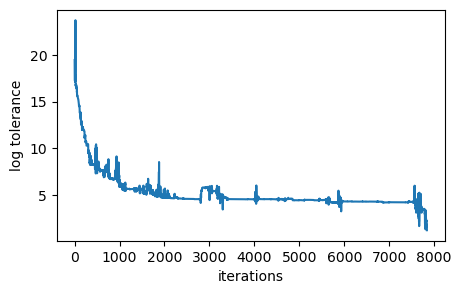

--> time = 9.65  min |  578.80 seconds
-> CGM converged?   True
-> Fit correctly?   True
!!!!  Sucess  !!!!
Building full visibility model...
F2D model in 9.93 minutes.


In [11]:
start_time = time.time()

kernel_params =  {'m': -2, 'c': 1e8, 'l': 1e5}
frank2d.fit(kernel_params = kernel_params, rtol = 1e-8 )

end_time = time.time()
print(f"F2D model in {(end_time - start_time)/60:.2f} minutes.")

# Plot

In [12]:
Plot_ = Plot(frank2d, geom)

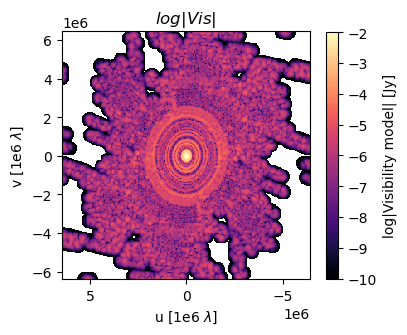

In [13]:
Plot_.visibility(fig_size = 4)

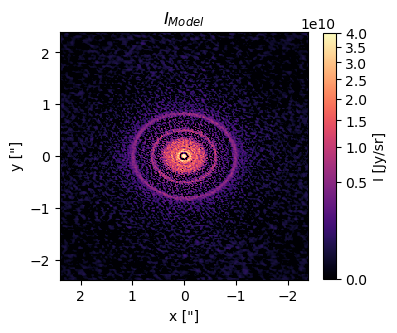

In [14]:
Plot_.intensity(fig_size = 4)

In [15]:
u, v, Re, Im, Weights = file['u'], file['v'], file['Re'], file['Im'], file['w']

In [16]:
uv_table = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights }

Performing 1D Frank fit...


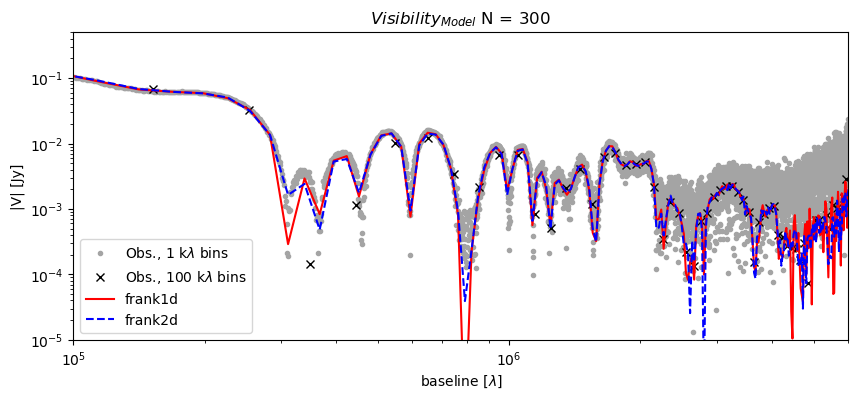

In [17]:
Plot_.visibility_profile(input = uv_table, weighted = True, frank1d = True)

In [18]:
dir =  "/Users/mariajmelladot/Desktop/Frank2D/data/fits/"
disk = disk_name + '_continuum.fits'
fits_file = dir + disk

	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
Performing 1D Frank fit...


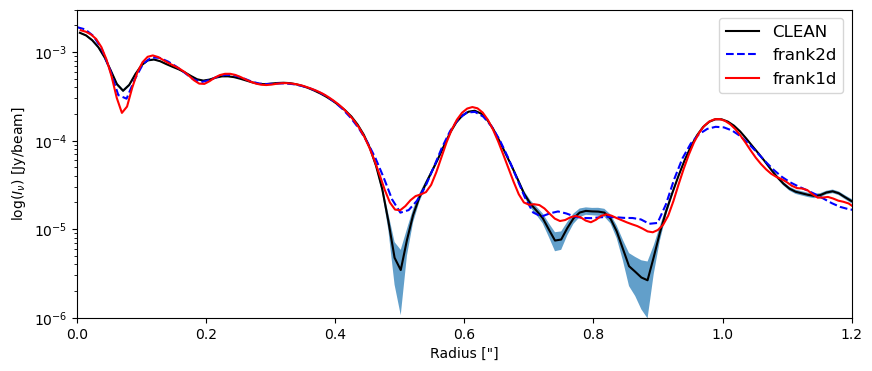

In [19]:
Plot_.intensity_profile(clean = True, fits_file = fits_file)